## 2.2.1 Import Libraries

The required libraries are imported for dataset preparation, CNN model development, training, evaluation, and visualization.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cu128
GPU Available: True


## 2.2.2 Set Device

The model is configured to use a GPU when available; otherwise, it runs on the CPU.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 2.2.3 Load and Preprocess CIFAR-10 Dataset

The CIFAR-10 dataset contains labeled color images belonging to 10 different classes. The images are converted into tensors and normalized before being provided to the CNN.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 170M/170M [28:31<00:00, 99.6kB/s]


Training samples: 50000
Testing samples: 10000


## 2.2.4 Dataset Classes

CIFAR-10 contains 10 image classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

In [4]:
classes = train_dataset.classes

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2.2.5 Inspect Image Dimensions

The dimensions and channels of sample images are inspected before training the CNN.

In [5]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", classes[label])

Image shape: torch.Size([3, 32, 32])
Label: 6
Class: frog


## 2.2.6 Sample Image Visualization

Sample images from the CIFAR-10 dataset are visualized to understand the type of images used for classification.

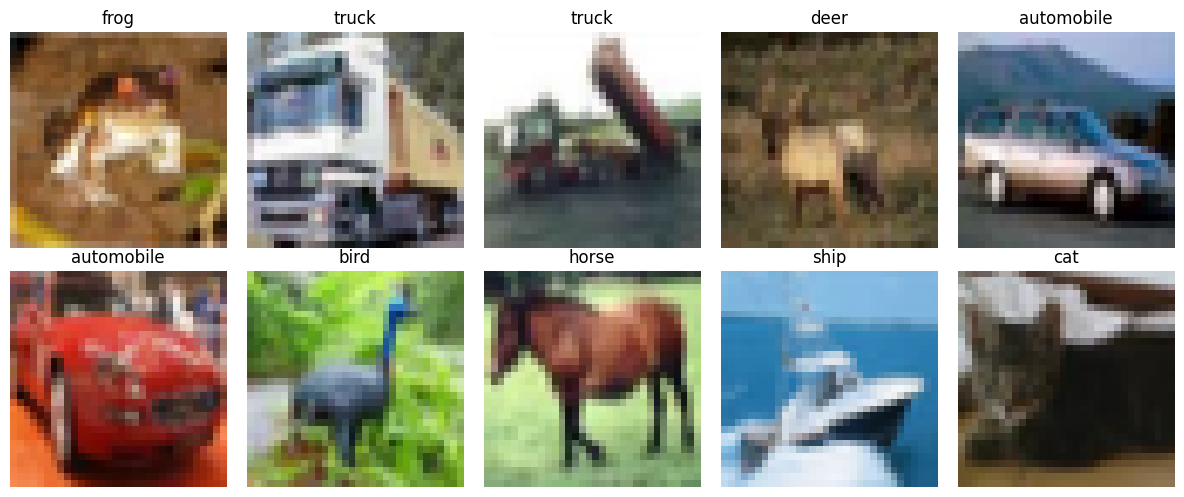

In [6]:
def show_images(dataset, num_images=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        image, label = dataset[i]

        image = image / 2 + 0.5
        image = image.permute(1, 2, 0).numpy()

        ax.imshow(image)
        ax.set_title(classes[label])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_images(train_dataset)

## 2.2.7 Create DataLoaders

DataLoaders are created to provide images to the CNN in batches during training and evaluation.

In [7]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 782
Testing batches: 157


## 2.2.8 Build the CNN Model

A Convolutional Neural Network is created using convolutional layers, ReLU activation functions, max-pooling layers, and fully connected layers for final classification.

In [8]:
class CNNClassifier(nn.Module):

    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNNClassifier().to(device)

print(model)

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 2.2.9 Define Loss Function and Optimizer

Cross-Entropy Loss is used for the multi-class classification problem. The Adam optimizer is used to update the CNN parameters during training.

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 2.2.10 Train the CNN

The CNN is trained for multiple epochs. Training loss and accuracy are recorded after each epoch.

In [10]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 1.4365 Accuracy: 47.84%
Epoch [2/5] Loss: 1.0182 Accuracy: 63.90%
Epoch [3/5] Loss: 0.8246 Accuracy: 71.25%
Epoch [4/5] Loss: 0.7042 Accuracy: 75.36%
Epoch [5/5] Loss: 0.6107 Accuracy: 78.70%


## 2.2.11 Evaluate the CNN

The trained CNN is evaluated on the test dataset to measure its classification accuracy.

In [11]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 74.47%


## 2.2.12 Training Loss Visualization

The training loss is visualized to observe how the CNN learns across epochs.

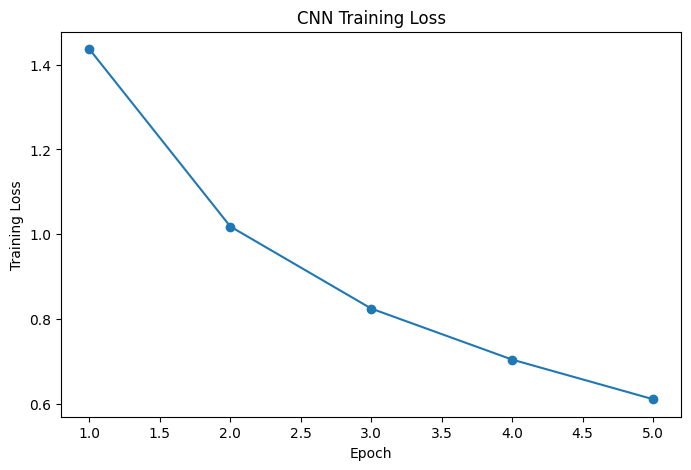

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.show()

## 2.2.13 Training Accuracy Visualization

Training accuracy is visualized to observe the classification performance of the CNN during training.

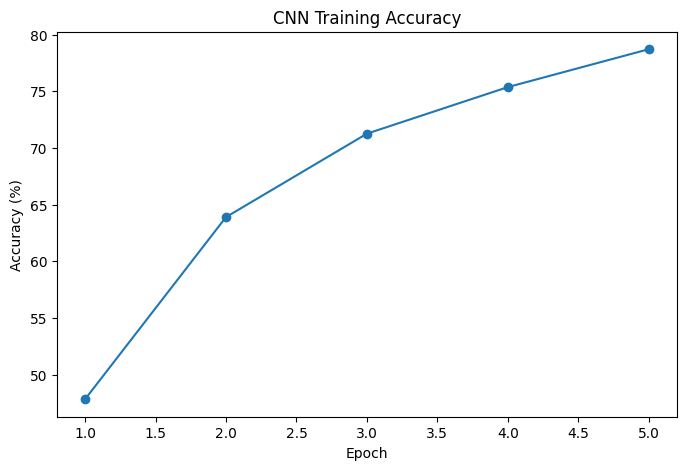

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training Accuracy")

plt.show()

## 2.2.14 Confusion Matrix

A confusion matrix is generated to analyze the classification performance across the ten CIFAR-10 classes.

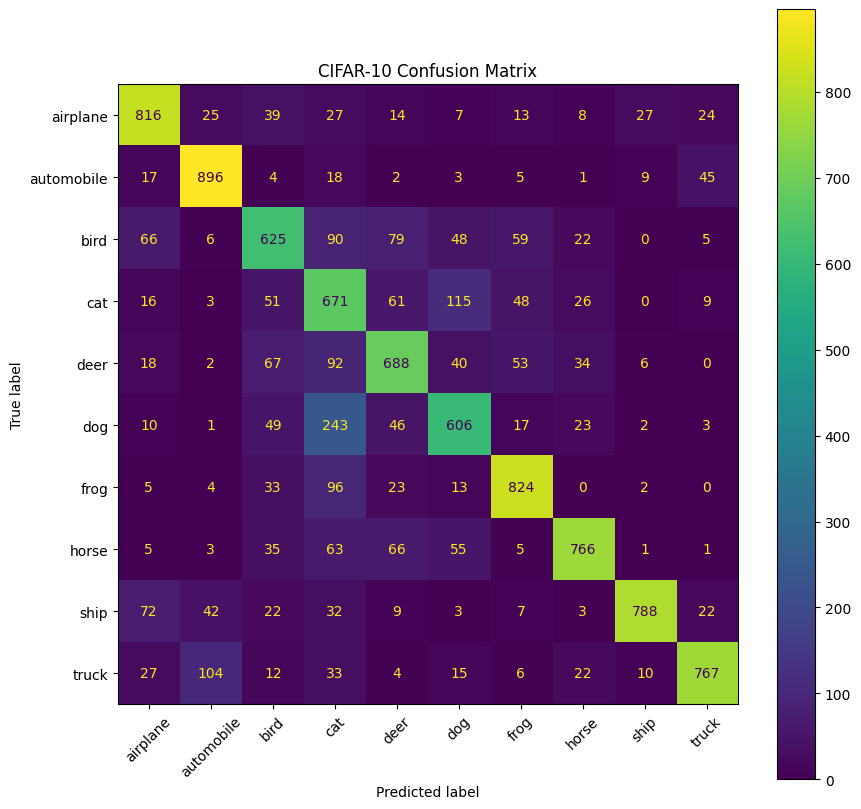

In [14]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("CIFAR-10 Confusion Matrix")
plt.show()

## 2.2.15 Correct and Incorrect Predictions

Sample predictions are inspected to identify correctly and incorrectly classified images.

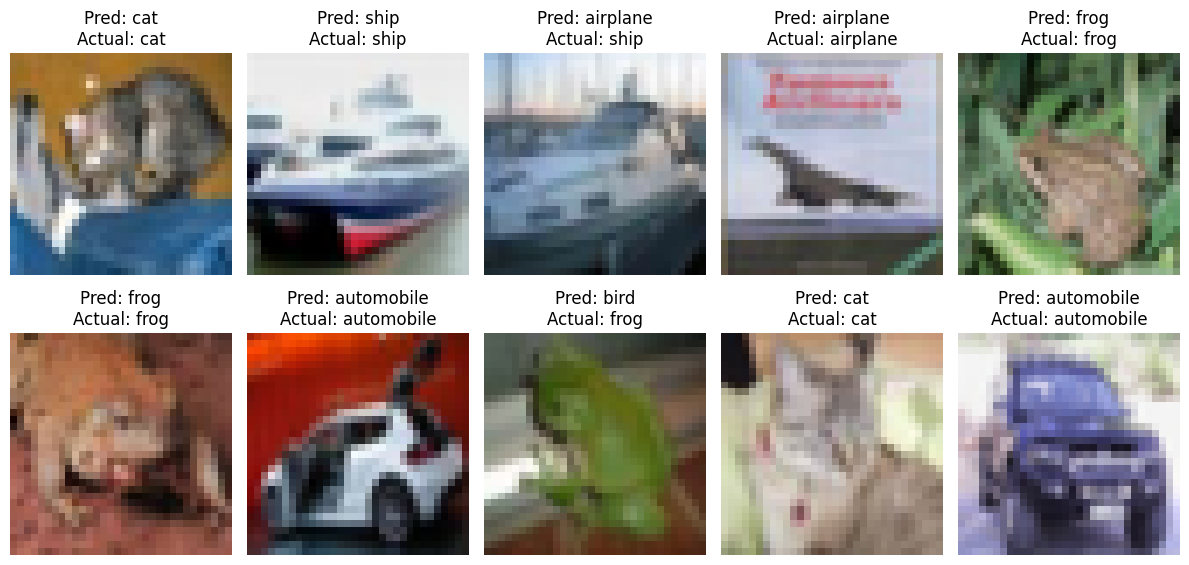

In [15]:
model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    predictions = torch.argmax(outputs, dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i] / 2 + 0.5
    image = image.permute(1, 2, 0).numpy()

    ax.imshow(image)

    predicted_class = classes[predictions[i]]
    actual_class = classes[labels[i]]

    ax.set_title(
        f"Pred: {predicted_class}\nActual: {actual_class}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 2.2.16 Save the Trained CNN Model

The trained CNN model is saved so that it can be reused without training the model again.

In [16]:
torch.save(
    model.state_dict(),
    "cifar10_cnn_model.pth"
)

print("CNN model saved successfully as cifar10_cnn_model.pth")

CNN model saved successfully as cifar10_cnn_model.pth


## 2.2.17 Save Preprocessing Configuration

The normalization values used during preprocessing are recorded so that the same preprocessing can be applied when the model is reused.

In [17]:
preprocessing_config = {
    "mean": (0.5, 0.5, 0.5),
    "std": (0.5, 0.5, 0.5),
    "image_size": (32, 32),
    "channels": 3
}

print("Preprocessing configuration:")
print(preprocessing_config)

Preprocessing configuration:
{'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'image_size': (32, 32), 'channels': 3}


## 2.2.18 Results Summary

The CNN was trained on the CIFAR-10 image dataset using PyTorch. The model learned image features through convolutional and pooling layers and classified images into ten categories. Training loss, training accuracy, test accuracy, sample predictions, and a confusion matrix were used to evaluate the model.

In [18]:
print("CNN Results Summary")
print("-------------------")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

CNN Results Summary
-------------------
Final Training Loss: 0.6107
Final Training Accuracy: 78.70%
Test Accuracy: 74.47%


## 2.2.19 Conclusion

A Convolutional Neural Network was successfully implemented using PyTorch for CIFAR-10 image classification. The workflow included image preprocessing, dataset inspection, DataLoaders, CNN architecture design, model training, evaluation, visualization, confusion matrix analysis, and model saving.